In [1]:
import tensorflow as tf
import datetime, os
#hide tf logs 
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # or any {'0', '1', '2'} 
#0 (default) shows all, 1 to filter out INFO logs, 2 to additionally filter out WARNING logs, and 3 to additionally filter out ERROR logs
import scipy.optimize
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
import time
from pyDOE import lhs         #Latin Hypercube Sampling
import seaborn as sns 
import codecs, json

# generates same random numbers each time
np.random.seed(1234)
tf.random.set_seed(1234)

print("TensorFlow version: {}".format(tf.__version__))

TensorFlow version: 2.10.0


# *Data Prep*

Training and Testing data is prepared from the solution file

In [2]:
data = scipy.io.loadmat('Data/burgers_shock_mu_01_pi.mat')  	# Load data from file
x = data['x']                                   # 256 points between -1 and 1 [256x1]
t = data['t']                                   # 100 time points between 0 and 1 [100x1] 
usol = data['usol']                             # solution of 256x100 grid points

X, T = np.meshgrid(x, t)                        # makes 2 arrays X and T such that u(X[i],T[j])=usol[i][j] are a tuple

In [3]:
# np.shape(X.flatten()[None,:])

# *Test Data*

We prepare the test data to compare against the solution produced by the PINN.

In [4]:
''' X_u_test = [X[i],T[i]] [25600,2] for interpolation'''
X_u_test = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))

# Domain bounds
lb = X_u_test[0]  # [-1. 0.]
ub = X_u_test[-1] # [1.  0.99]

'''
   Fortran Style ('F') flatten,stacked column wise!
   u = [c1 
        c2
        .
        .
        cn]

   u =  [25600x1] 
'''
u = usol.flatten('F')[:,None] 

In [5]:
u.shape

(25600, 1)

# *Training Data*

The boundary conditions serve as the test data for the PINN and the collocation points are generated using **Latin Hypercube Sampling**

In [6]:
def trainingdata(N_b, N_f):
#### def trainingdata(N_b, N_f, N_l):

    '''labelled data inside the domain'''
    
####     X_all_labelled = np.hstack((X.flatten()[:,None], T.flatten()[:,None])) # all labelled X's
####     u_all_labelled = usol.flatten('F')[:,None] # all labelled u's
####     idx_l = np.random.choice(X_all_labelled.shape[0], N_l, replace=False) # the index of laballed data
####     X_labelled = X_all_labelled[idx_l, :] # choose (x,t) pairs from the set X_all_labelled with indices 'idx_l'
####     u_labelled = u_all_labelled[idx_l, :] # choose u's from the set u_all_labelled with indices 'idx_l'

    '''the data that should meet the Boundary Conditions'''

    #Initial Condition -1 =< x =<1 and t = 0  
    leftedge_x = np.hstack((X[0,:][:,None], T[0,:][:,None])) #L1
    leftedge_u = usol[:,0][:,None]

    #Boundary Condition x = -1 and 0 =< t =<1
    bottomedge_x = np.hstack((X[:,0][:,None], T[:,0][:,None])) #L2
    bottomedge_u = usol[-1,:][:,None] # bottomedge_u = usol[0,:][:,None]

    #Boundary Condition x = 1 and 0 =< t =<1
    topedge_x = np.hstack((X[:,-1][:,None], T[:,0][:,None])) #L3
    topedge_u = usol[0,:][:,None] # topedge_u = usol[-1,:][:,None]

    all_X_u_train = np.vstack([leftedge_x, bottomedge_x, topedge_x]) # all_X_u_train [456,2] (456 = 256(L1)+100(L2)+100(L3))
    all_u_train = np.vstack([leftedge_u, bottomedge_u, topedge_u])   #and the corresponding u [456x1]

    #choose random N_u points for training
    idx_b = np.random.choice(all_X_u_train.shape[0], N_b, replace=False) # index of boundary points

    X_u_train = all_X_u_train[idx_b, :] #choose indices from  set 'idx_b' (x,t)
    u_train = all_u_train[idx_b,:]      #choose corresponding u

    '''Residual PDE Points'''

    # Latin Hypercube sampling for collocation points 
    # N_f sets of tuples(x,t)
    X_f_train = lb + (ub-lb)*lhs(2, N_f) 
    X_f_train = np.vstack((X_f_train, X_u_train)) # append training points to collocation points 

    return X_f_train, X_u_train, u_train 
#### return X_f_train, X_u_train, u_train, X_labelled, u_labelled


# **PINN**

Generate a **PINN** of L hidden layers, each with n neurons. 

Initialization: ***Xavier***

Activation: *tanh (x)*

In [7]:
class Sequentialmodel(tf.Module): 
    def __init__(self, layers, name=None):
       
        self.W = []  #Weights and biases
        self.parameters = 0 #total number of parameters
        self.iteration = 0
        self.losss_history = np.array([])
        self.error_history = np.array([])
        
        for i in range(len(layers)-1):
            
            input_dim = layers[i]
            output_dim = layers[i+1]
            
            #Xavier standard deviation 
            std_dv = np.sqrt((2.0/(input_dim + output_dim)))

            #weights = normal distribution * Xavier standard deviation + 0
            w = tf.random.normal([input_dim, output_dim], dtype = 'float64') * std_dv                       
            w = tf.Variable(w, trainable=True, name = 'w' + str(i+1))
            b = tf.Variable(tf.cast(tf.zeros([output_dim]), dtype = 'float64'), trainable = True, name = 'b' + str(i+1))                    
            self.W.append(w)
            self.W.append(b)            
            self.parameters +=  input_dim * output_dim + output_dim
    
    def evaluate(self, x):
        
        x = (x-lb)/(ub-lb)        
        a = x        
        for i in range(len(layers)-2):            
            z = tf.add(tf.matmul(a, self.W[2*i]), self.W[2*i+1])
            a = tf.nn.tanh(z)            
        a = tf.add(tf.matmul(a, self.W[-2]), self.W[-1]) # For regression, no activation to last layer
        return a
    
    def get_weights(self):

        parameters_1d = []  # [.... W_i,b_i.....  ] 1d array
        
        for i in range (len(layers)-1):
            
            w_1d = tf.reshape(self.W[2*i],[-1])   #flatten weights 
            b_1d = tf.reshape(self.W[2*i+1],[-1]) #flatten biases
            
            parameters_1d = tf.concat([parameters_1d, w_1d], 0) #concat weights 
            parameters_1d = tf.concat([parameters_1d, b_1d], 0) #concat biases
        
        return parameters_1d
        
    def set_weights(self,parameters):
                
        for i in range (len(layers)-1):

            shape_w = tf.shape(self.W[2*i]).numpy() # shape of the weight tensor
            size_w = tf.size(self.W[2*i]).numpy() #size of the weight tensor 
            
            shape_b = tf.shape(self.W[2*i+1]).numpy() # shape of the bias tensor
            size_b = tf.size(self.W[2*i+1]).numpy() #size of the bias tensor 
                        
            pick_w = parameters[0:size_w] #pick the weights 
            self.W[2*i].assign(tf.reshape(pick_w,shape_w)) # assign  
            parameters = np.delete(parameters,np.arange(size_w),0) #delete 
            
            pick_b = parameters[0:size_b] #pick the biases 
            self.W[2*i+1].assign(tf.reshape(pick_b,shape_b)) # assign 
            parameters = np.delete(parameters,np.arange(size_b),0) #delete 
    
#     def loss_labelled(self, x, y):
#         loss_l = tf.reduce_mean(tf.square(y-self.evaluate(x)))
#         return loss_l
            
    def loss_BC(self, x, y):
        loss_u = tf.reduce_mean(tf.square(y-self.evaluate(x)))
        return loss_u

    def loss_PDE(self, x_to_train_f):
    
        g = tf.Variable(x_to_train_f, dtype = 'float64', trainable = False)
    
        lambda2 = 0.01/np.pi

        x_f = g[:,0:1]
        t_f = g[:,1:2]

        with tf.GradientTape(persistent=True) as tape:

            tape.watch(x_f)
            tape.watch(t_f)

            g = tf.stack([x_f[:,0], t_f[:,0]], axis=1)   
            z = self.evaluate(g)
            u_x = tape.gradient(z, x_f)

        u_t = tape.gradient(z, t_f)    
        u_xx = tape.gradient(u_x, x_f)

        del tape

        f = u_t + (self.evaluate(g))*(u_x) - lambda2*u_xx #### why not use z?

        loss_f = tf.reduce_mean(tf.square(f))

        return loss_f
    
    def loss(self, x, y, g):
####         loss_l = self.loss_labelled(x, y)
        loss_u = self.loss_BC(x, y)
        loss_f = self.loss_PDE(g)

        loss = loss_u + loss_f
####         loss = loss_u + loss_f + loss_l

        return loss, loss_u, loss_f
####         return loss, loss_u, loss_f, loss_l
    
    def optimizerfunc(self, parameters):
        
        self.set_weights(parameters)
       
        with tf.GradientTape() as tape:
            tape.watch(self.trainable_variables)
            
            loss_val, loss_u, loss_f = self.loss(X_u_train, u_train, X_f_train)
#             loss_val, loss_u, loss_f, loss_l = self.loss(X_u_train, u_train, X_f_train, X_labelled, u_labelled)
#             print(loss_val)
        grads = tape.gradient(loss_val, self.trainable_variables)
#         print(grads)        
        del tape
        
        grads_1d = [ ] #flatten grads 
        
        for i in range (len(layers)-1):

            grads_w_1d = tf.reshape(grads[2*i], [-1]) #flatten weights 
            grads_b_1d = tf.reshape(grads[2*i+1], [-1]) #flatten biases

            grads_1d = tf.concat([grads_1d, grads_w_1d], 0) #concat grad_weights 
            grads_1d = tf.concat([grads_1d, grads_b_1d], 0) #concat grad_biases

        return loss_val.numpy(), grads_1d.numpy()
    
    def optimizer_callback(self, parameters):
        self.iteration += 1
        
        loss_value, loss_u, loss_f = self.loss(X_u_train, u_train, X_f_train)
        
        u_pred = self.evaluate(X_u_test)
        error = np.linalg.norm((u-u_pred),2)/np.linalg.norm(u,2)
        self.error_history = np.append(self.error_history, error)
        
        self.losss_history = np.append(self.losss_history, loss_value.numpy())
        print('iteration', self.iteration, 'error:', error, 'loss_value:', loss_value.numpy())

# *Solution Plot*

In [8]:
def solutionplot(u_pred,X_u_train,u_train):
    
    fig, ax = plt.subplots()
    ax.axis('off')

    gs0 = gridspec.GridSpec(1, 2)
    gs0.update(top=1-0.06, bottom=1-1/3, left=0.15, right=0.85, wspace=0)
    ax = plt.subplot(gs0[:, :])

    h = ax.imshow(u_pred, interpolation='nearest', cmap='rainbow', 
                extent=[T.min(), T.max(), X.min(), X.max()], 
                origin='lower', aspect='auto')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(h, cax=cax)
    
    ax.plot(X_u_train[:,1], X_u_train[:,0], 'kx', label = 'Data (%d points)' % (u_train.shape[0]), markersize = 4, clip_on = False)

    line = np.linspace(x.min(), x.max(), 2)[:,None]
    ax.plot(t[25]*np.ones((2,1)), line, 'w-', linewidth = 1)
    ax.plot(t[50]*np.ones((2,1)), line, 'w-', linewidth = 1)
    ax.plot(t[75]*np.ones((2,1)), line, 'w-', linewidth = 1)    

    ax.set_xlabel('$t$')
    ax.set_ylabel('$x$')
    ax.legend(frameon=False, loc = 'best')
    ax.set_title('$u(x,t)$', fontsize = 10)
    
    ''' 
    Slices of the solution at points t = 0.25, t = 0.50 and t = 0.75
    '''
    
    ####### Row 1: u(t,x) slices ##################
    gs1 = gridspec.GridSpec(1, 3)
    gs1.update(top=1-1/3, bottom=0, left=0.1, right=0.9, wspace=0.5)

    ax = plt.subplot(gs1[0, 0])
    ax.plot(x,usol.T[25,:], 'b-', linewidth = 2, label = 'Exact')       
    ax.plot(x,u_pred.T[25,:], 'r--', linewidth = 2, label = 'Prediction')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$u(x,t)$')    
    ax.set_title('$t = 0.25s$', fontsize = 10)
    ax.axis('square')
    ax.set_xlim([-1.1,1.1])
    ax.set_ylim([-1.1,1.1])

    ax = plt.subplot(gs1[0, 1])
    ax.plot(x,usol.T[50,:], 'b-', linewidth = 2, label = 'Exact')       
    ax.plot(x,u_pred.T[50,:], 'r--', linewidth = 2, label = 'Prediction')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$u(x,t)$')
    ax.axis('square')
    ax.set_xlim([-1.1,1.1])
    ax.set_ylim([-1.1,1.1])
    ax.set_title('$t = 0.50s$', fontsize = 10)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=5, frameon=False)

    ax = plt.subplot(gs1[0, 2])
    ax.plot(x,usol.T[75,:], 'b-', linewidth = 2, label = 'Exact')       
    ax.plot(x,u_pred.T[75,:], 'r--', linewidth = 2, label = 'Prediction')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$u(x,t)$')
    ax.axis('square')
    ax.set_xlim([-1.1,1.1])
    ax.set_ylim([-1.1,1.1])    
    ax.set_title('$t = 0.75s$', fontsize = 10)
    
    plt.savefig('Burgers.png',dpi = 500)   

# *Model Training and Testing*

A function '**model**' is defined to generate a NN as per the input set of hyperparameters, which is then trained and tested. The L2 Norm of the solution error is returned as a comparison metric

iteration 1 error: 0.9590025379122513 loss_value: 0.23502230522604572
iteration 2 error: 0.9477675000867978 loss_value: 0.22933238946946405
iteration 3 error: 0.8605706219067619 loss_value: 0.21656462481543548
iteration 4 error: 0.8630361736422396 loss_value: 0.21216994928944097
iteration 5 error: 0.8846862718865861 loss_value: 0.210228600846857
iteration 6 error: 0.8809333178376606 loss_value: 0.20945584416642865
iteration 7 error: 0.8749921994686276 loss_value: 0.20685245553849294
iteration 8 error: 0.8784960363386147 loss_value: 0.2050022558774187
iteration 9 error: 0.887204005781698 loss_value: 0.2034702293635633
iteration 10 error: 0.8908606033245772 loss_value: 0.20296442681805724
iteration 11 error: 0.8945015683514068 loss_value: 0.2020649923869781
iteration 12 error: 0.8968230681517293 loss_value: 0.20113503642020106
iteration 13 error: 0.8994575663049381 loss_value: 0.2006465434239929
iteration 14 error: 0.893059872269884 loss_value: 0.199533450618496
iteration 15 error: 0.889

iteration 112 error: 0.5294856806301411 loss_value: 0.06044374921465606
iteration 113 error: 0.5066066827659246 loss_value: 0.060037821703264216
iteration 114 error: 0.5064418281804476 loss_value: 0.059133354268330884
iteration 115 error: 0.502375353430345 loss_value: 0.05876811858926038
iteration 116 error: 0.49740762724113147 loss_value: 0.05823356234437595
iteration 117 error: 0.5001067251290164 loss_value: 0.05760232127448237
iteration 118 error: 0.4874061806182232 loss_value: 0.05690605985772632
iteration 119 error: 0.4958633699756113 loss_value: 0.056347907000564725
iteration 120 error: 0.49219458248254694 loss_value: 0.05620009507278374
iteration 121 error: 0.4924808401819277 loss_value: 0.055940649665120246
iteration 122 error: 0.49187028525161636 loss_value: 0.05584522923124037
iteration 123 error: 0.49092999219530054 loss_value: 0.05571064176406745
iteration 124 error: 0.4905259074581183 loss_value: 0.05530965117461801
iteration 125 error: 0.48335439496253146 loss_value: 0.05

iteration 225 error: 0.35648277717200466 loss_value: 0.021754538870331144
iteration 226 error: 0.35291018042459166 loss_value: 0.021528248398449745
iteration 227 error: 0.35663820451995865 loss_value: 0.02127626677809019
iteration 228 error: 0.3547067227255203 loss_value: 0.02107818341595613
iteration 229 error: 0.35433080021932556 loss_value: 0.020877318520858112
iteration 230 error: 0.35114780842313237 loss_value: 0.020628155691694256
iteration 231 error: 0.35113167088843905 loss_value: 0.020372679499070456
iteration 232 error: 0.3480640319055295 loss_value: 0.019709526634210425
iteration 233 error: 0.34970147257040457 loss_value: 0.019441765915710934
iteration 234 error: 0.3481425170787591 loss_value: 0.019174077488663878
iteration 235 error: 0.34398350071192 loss_value: 0.018969416174174032
iteration 236 error: 0.34151328719486607 loss_value: 0.018623404718639852
iteration 237 error: 0.33669791745004335 loss_value: 0.018385376722615213
iteration 238 error: 0.3325986605845053 loss_v

iteration 337 error: 0.25109856610913744 loss_value: 0.004864431036347572
iteration 338 error: 0.2500961031912394 loss_value: 0.004714923008953681
iteration 339 error: 0.2503739390654064 loss_value: 0.004616236773030873
iteration 340 error: 0.25176190490334643 loss_value: 0.004564304016156957
iteration 341 error: 0.24997551539998972 loss_value: 0.004531019748303237
iteration 342 error: 0.25053487104794414 loss_value: 0.004506470130348048
iteration 343 error: 0.25066321493447447 loss_value: 0.0044900476515690535
iteration 344 error: 0.25053856600238 loss_value: 0.004471376647950847
iteration 345 error: 0.2498312472175233 loss_value: 0.004422687451296073
iteration 346 error: 0.24933067196990344 loss_value: 0.004364696275978947
iteration 347 error: 0.24858707669170887 loss_value: 0.004270605354028157
iteration 348 error: 0.24896051454865925 loss_value: 0.004208792846723191
iteration 349 error: 0.24909508215125845 loss_value: 0.004165941195320551
iteration 350 error: 0.24883247142598303 lo

iteration 448 error: 0.1909860584749397 loss_value: 0.0011926882122071229
iteration 449 error: 0.19184222884886024 loss_value: 0.0011728454996782142
iteration 450 error: 0.19148145537801667 loss_value: 0.0011639706219747897
iteration 451 error: 0.19042139407957206 loss_value: 0.0011574975334980803
iteration 452 error: 0.18855581495739243 loss_value: 0.0011555056017156877
iteration 453 error: 0.18873373263223114 loss_value: 0.0011488092400185348
iteration 454 error: 0.18831658463266346 loss_value: 0.0011468912166895057
iteration 455 error: 0.18745083911702645 loss_value: 0.0011424192806551304
iteration 456 error: 0.18609821710342436 loss_value: 0.0011365710164960607
iteration 457 error: 0.18531121123487607 loss_value: 0.0011293008105623674
iteration 458 error: 0.18411439441182895 loss_value: 0.0011184101512025924
iteration 459 error: 0.1843759669932778 loss_value: 0.0011083016901219623
iteration 460 error: 0.18474581575910812 loss_value: 0.0010973040300230636
iteration 461 error: 0.1867

...

iteration 667 error: 0.058060017313824264 loss_value: 0.00021486328006530675
iteration 668 error: 0.05818498699107881 loss_value: 0.00021376191336606242
iteration 669 error: 0.05997010333391788 loss_value: 0.00021282290038595909
iteration 670 error: 0.06416260920608914 loss_value: 0.00021176597671580002
iteration 671 error: 0.06608583197155805 loss_value: 0.0002111180800589653
iteration 672 error: 0.06652367302092009 loss_value: 0.0002106559267069897
iteration 673 error: 0.0674114670423543 loss_value: 0.00021031027687545904
iteration 674 error: 0.0676119634477486 loss_value: 0.000210007924031219
iteration 675 error: 0.06757271279074004 loss_value: 0.00020949940371030738
iteration 676 error: 0.06711648457564488 loss_value: 0.0002087475986293737
iteration 677 error: 0.06626838059368818 loss_value: 0.00020788096513658087
iteration 678 error: 0.06457823880305949 loss_value: 0.00020644114204745103
iteration 679 error: 0.06517207591877747 loss_value: 0.0002056425405585686
iteration 680 error

iteration 775 error: 0.013257765171103655 loss_value: 0.00011325662822378522
iteration 776 error: 0.013219637953614314 loss_value: 0.00011310225169321343
iteration 777 error: 0.013164778154464169 loss_value: 0.00011281193266763192
iteration 778 error: 0.012972812749280289 loss_value: 0.00011250288909654174
iteration 779 error: 0.012756287617083402 loss_value: 0.00011206340642389739
iteration 780 error: 0.012572124499311228 loss_value: 0.00011164828949074344
iteration 781 error: 0.012508869981777495 loss_value: 0.00011118230586906646
iteration 782 error: 0.012909512834991234 loss_value: 0.0001109800246306461
iteration 783 error: 0.013059480297947483 loss_value: 0.00011026394710530138
iteration 784 error: 0.013181467442889429 loss_value: 0.00010984949239613981
iteration 785 error: 0.013706797396078073 loss_value: 0.00010928703980439918
iteration 786 error: 0.013963464537614895 loss_value: 0.00010891573612799412
iteration 787 error: 0.013898547606781546 loss_value: 0.00010854308715455699


iteration 883 error: 0.009513253427716417 loss_value: 7.503469976002708e-05
iteration 884 error: 0.009859346929521895 loss_value: 7.423761350678208e-05
iteration 885 error: 0.009963389999581601 loss_value: 7.35942440922107e-05
iteration 886 error: 0.01016716920001005 loss_value: 7.309519278491075e-05
iteration 887 error: 0.010080619521705834 loss_value: 7.285635528341763e-05
iteration 888 error: 0.009520203931447072 loss_value: 7.257246265187284e-05
iteration 889 error: 0.009452127289998731 loss_value: 7.24126159336832e-05
iteration 890 error: 0.009318444065818719 loss_value: 7.228265799938615e-05
iteration 891 error: 0.009208771397093349 loss_value: 7.218539244205966e-05
iteration 892 error: 0.00916150233930291 loss_value: 7.212359092067409e-05
iteration 893 error: 0.009196271238481945 loss_value: 7.207675213116133e-05
iteration 894 error: 0.009245126646567008 loss_value: 7.203836925053446e-05
iteration 895 error: 0.009334147712837705 loss_value: 7.199011863917863e-05
iteration 896 er

iteration 992 error: 0.008406174270009075 loss_value: 4.96895843341706e-05
iteration 993 error: 0.008225677991150407 loss_value: 4.933308322122399e-05
iteration 994 error: 0.008516770605775353 loss_value: 4.908586809505833e-05
iteration 995 error: 0.008214309292916973 loss_value: 4.8660248993570626e-05
iteration 996 error: 0.00757277989958836 loss_value: 4.8282933424080206e-05
iteration 997 error: 0.0074394802331582245 loss_value: 4.819663418082791e-05
iteration 998 error: 0.007715730909516582 loss_value: 4.79613165910009e-05
iteration 999 error: 0.007865237432855662 loss_value: 4.789950194615372e-05
iteration 1000 error: 0.007983617697242117 loss_value: 4.7806526249638683e-05
Training time: 7.37
  message: STOP: TOTAL NO. of ITERATIONS REACHED LIMIT
  success: False
   status: 1
      fun: 4.7806526249638683e-05
        x: [-1.201e+00 -3.361e-01 ... -5.312e-02  4.610e-02]
      nit: 1000
      jac: [ 8.529e-05  4.434e-06 ...  3.404e-04 -1.207e-03]
     nfev: 1054
     njev: 1054
 hess

C:\Users\2233939\AppData\Local\Temp\1\ipykernel_8644\2557923201.py:8: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(gs0[:, :])


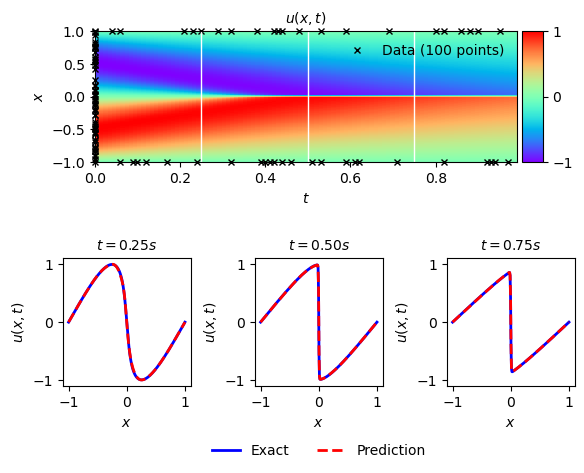

In [9]:
N_u = 100 #Total number of data points for 'u'
N_f = 10000 #Total number of collocation points 

# Training data
X_f_train, X_u_train, u_train = trainingdata(N_u, N_f)

layers = np.array([2,20,20,20,20,20,20,20,20,1]) #8 hidden layers

PINN = Sequentialmodel(layers)

init_params = PINN.get_weights().numpy()

start_time = time.time() 

# train the model with Scipy L-BFGS optimizer
results = scipy.optimize.minimize(fun = PINN.optimizerfunc, 
                                  x0 = init_params, 
                                  args=(), 
                                  method='L-BFGS-B', 
                                  jac= True,        # If jac is True, fun is assumed to return the gradient along with the objective function
                                  callback = PINN.optimizer_callback, 
                                  options = {'disp': None,
                                            'maxcor': 200, 
                                            'ftol': 1 * np.finfo(float).eps,  #The iteration stops when (f^k - f^{k+1})/max{|f^k|,|f^{k+1}|,1} <= ftol
                                            'gtol': 5e-8, 
                                            'maxfun':  50000, 
                                            'maxiter': 1000,
                                            'iprint': -1,   #print update every 50 iterations
                                            'maxls': 50})

elapsed = time.time() - start_time                
print('Training time: %.2f' % (elapsed/60.0))

print(results)

PINN.set_weights(results.x)

''' Model Accuracy ''' 
u_pred = PINN.evaluate(X_u_test)

error_vec = np.linalg.norm((u-u_pred),2)/np.linalg.norm(u,2)        # Relative L2 Norm of the error (Vector)
print('Test Error: %.5f'  % (error_vec))

u_pred = np.reshape(u_pred, (256,100), order='F')                        # Fortran Style ,stacked column wise!

''' Solution Plot '''
solutionplot(u_pred, X_u_train, u_train)

# Plot of collocation points

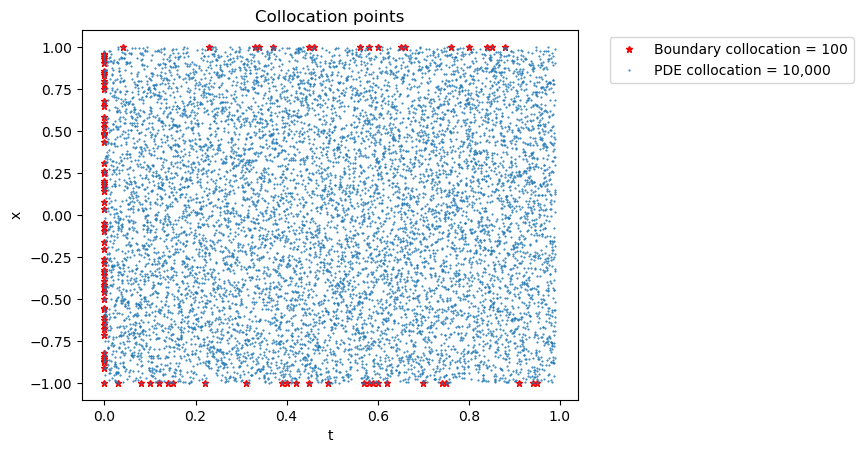

In [10]:
N_u = 100 #Total number of data points for 'u'
N_f = 10000 #Total number of collocation points 

# Training data
X_f_train, X_u_train, u_train = trainingdata(N_u, N_f)

fig,ax = plt.subplots()

plt.plot(X_u_train[:,1], X_u_train[:,0], '*', color = 'red', markersize = 5, label = 'Boundary collocation = 100')
plt.plot(X_f_train[:,1], X_f_train[:,0], 'o', markersize = 0.5, label = 'PDE collocation = 10,000')

plt.xlabel('t')
plt.ylabel('x')
plt.title('Collocation points')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

fig.savefig('collocation_points_Burgers.png', dpi = 500, bbox_inches='tight')

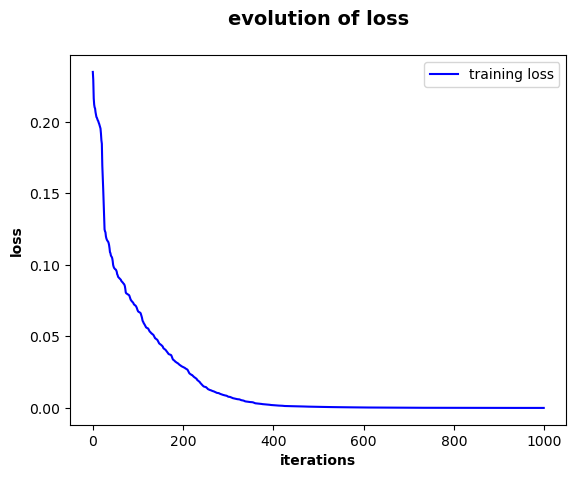

In [11]:
# PINN.losss_history
fig, ax = plt.subplots()  
ax.plot(PINN.losss_history, 'b')
# ax.set_ylim(0, 5)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('loss', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('evolution of loss\n', fontsize = 14, fontweight ='bold')
plt.savefig('loss.png')
plt.legend(['training loss'])
plt.show()

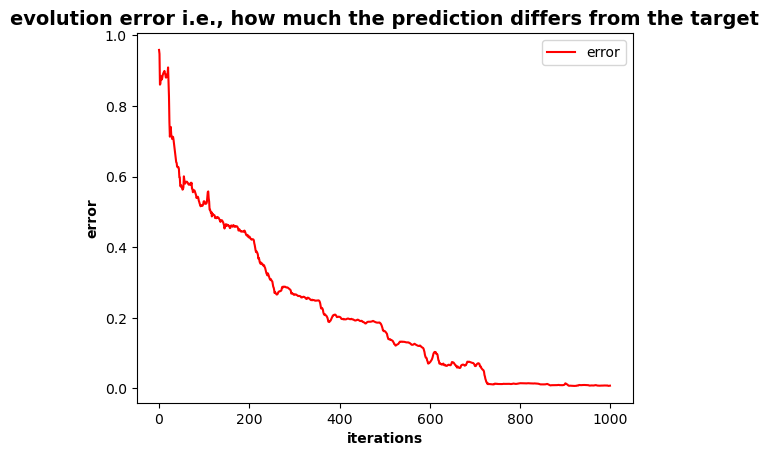

In [12]:
fig, ax = plt.subplots()  
ax.plot(PINN.error_history, 'r')
# ax.set_xlim(5, 0)
ax.set_xlabel('iterations', 
               fontweight ='bold')
ax.set_ylabel('error', 
               fontweight ='bold')
# ax.grid(True)
  
ax.set_title('evolution error i.e., how much the prediction differs from the target', fontsize = 14, fontweight ='bold')
plt.savefig('error history.png')
plt.legend(['error'])
plt.show()

In [13]:
len(PINN.trainable_variables)

18